# Executive Objective

The objective of this analysis is to diagnose the drivers of revenue contraction observed in Q1 2024 relative to Q4 2023 by systematically decomposing revenue performance across volume, customer segments, channels, geography, and behavioral metrics. The analysis aims to determine whether the decline was driven by pricing pressure, demand contraction, operational deterioration, or segment-specific underperformance, and to isolate the primary financial contributors to the slowdown in order to inform targeted strategic action.

# Imports & Environment Setup

In [97]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import matplotlib.ticker as mtick

# Data Loading

## Load Dataset

In [98]:
# setting pandas print options
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


# suppressing warnings
warnings.filterwarnings(action = 'ignore')


# reading the file into Python
ecom_df = pd.read_csv('ecommerce_customer_behavior_dataset_v2.csv')

## Basic Inspection

In [99]:
# Displaying the first 5 records
ecom_df.head(n = 5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [100]:
# Checking dataset shape
ecom_df.shape

(17049, 18)

The dataset has over 17K observations and 18 features.

In [101]:
# Checking data types & missing values
ecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

no missing values found and only date needs data type fixing.  

In [102]:
# dataset description
ecom_df.describe().round(2)

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.00,17049.00,17049.00,17049.00,17049.00,17049.00,17049.00,17049.00,17049.00
mean,34.95,447.90,3.01,69.79,1277.44,14.54,9.00,6.50,3.90
std,11.05,722.32,1.42,240.70,2358.44,2.93,2.26,3.49,1.13
min,18.00,5.05,1.00,0.00,6.21,4.00,1.00,1.00,1.00
25%,26.00,73.26,2.00,0.00,172.97,13.00,7.00,4.00,3.00
50%,35.00,174.68,3.00,0.00,455.85,15.00,9.00,6.00,4.00
75%,42.00,494.57,4.00,32.71,1267.75,17.00,11.00,8.00,5.00
max,75.00,7900.01,5.00,6538.29,37852.05,26.00,18.00,25.00,5.00


Revenue-related metrics such as unit price, discount, and total amount are positively skewed.

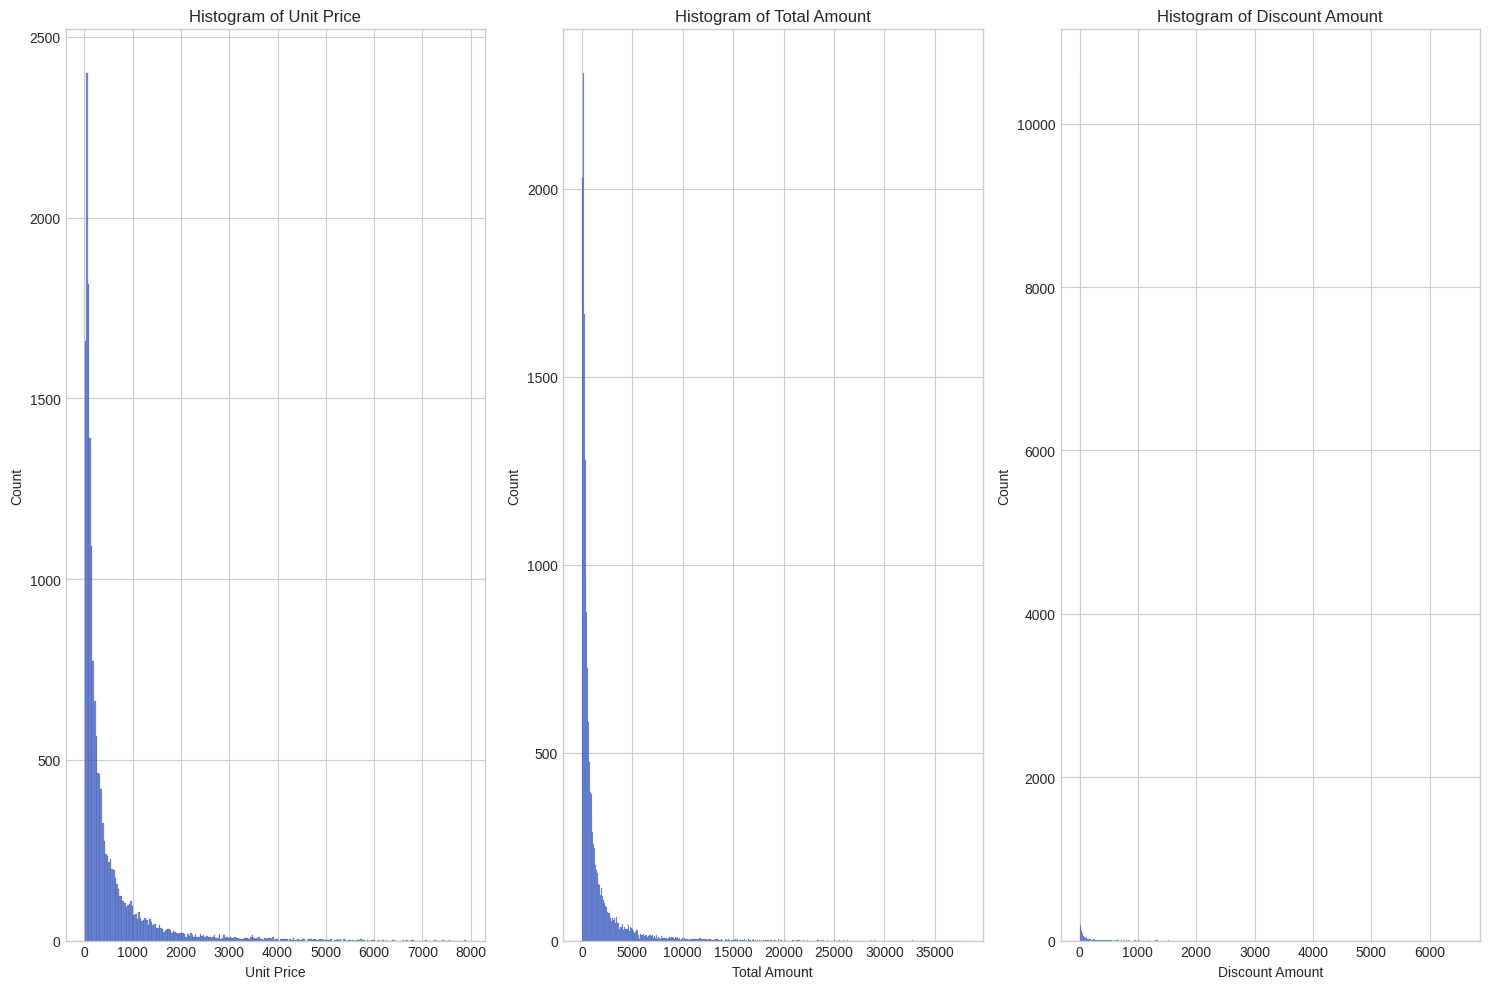

In [103]:
## Histogram distributions for the skewed features##

# setting figure size
fig, ax = plt.subplots(nrows=1, ncols = 3, figsize = (15, 10))

#Histogram 1
sns.histplot(x             = ecom_df['Unit_Price'],
                color      = 'royalblue',
                ax         =  ax[0])

#setting up labels
ax[0].set_title(label   = """Histogram of Unit Price""")
ax[0].set_xlabel(xlabel = 'Unit Price')
ax[0].set_ylabel(ylabel = 'Count')


#Histogram 2
sns.histplot(x             = ecom_df['Total_Amount'],
                color      = 'royalblue',
                ax         = ax[1])

#setting up labels
ax[1].set_title(label   = """Histogram of Total Amount""")
ax[1].set_xlabel(xlabel = 'Total Amount')
ax[1].set_ylabel(ylabel = 'Count')

#Histogram 3
sns.histplot(x             = ecom_df['Discount_Amount'],
                color      = 'royalblue',
                ax         = ax[2])


#setting up labels
ax[2].set_title(label   = """Histogram of Discount Amount""")
ax[2].set_xlabel(xlabel = 'Discount Amount')
ax[2].set_ylabel(ylabel = 'Count')

# cleaning up layout and rendering visual
plt.tight_layout()
plt.show()

The first two distributions are right-skewed, indicating that most transactions occur at lower values, while the discount amount distribution suggests that discounts were applied in relatively few cases.

# Data Cleaning & Validation

## Feature Engineering Validation

In [104]:
# Recalculate Total Amount
calculated_total = (
    ecom_df['Unit_Price'] * ecom_df['Quantity']
    - ecom_df['Discount_Amount']
)

# Check for Differences
difference = (
    ecom_df['Total_Amount'] - calculated_total
)

# Confirm Validation
difference.abs().sum()

np.float64(8.042224663995512e-10)

The recalculated revenue metric showed only negligible floating-point differences (≈ 0), confirming that Total Amount is correctly derived from Unit Price, Quantity, and Discount.

## Create Time Features

In [105]:
# Convert date from object to datetime
ecom_df['Date'] = pd.to_datetime(ecom_df['Date'])

# Year
ecom_df['year'] = ecom_df['Date'].dt.year

# Month (numeric)
ecom_df['month'] = ecom_df['Date'].dt.month

# Year-Month
ecom_df['year_month'] = ecom_df['Date'].dt.to_period('M')

# Quarter
ecom_df['quarter'] = ecom_df['Date'].dt.to_period('Q')

Time-based features (Year, Month, Year-Month, and Quarter) were derived from the transaction date to enable revenue trend analysis, seasonality evaluation, and quarterly performance assessment.

# Feature Engineering

## Business KPIs

In [106]:
# Order Count
order_count = ecom_df.shape[0]

# Revenue
revenue = ecom_df['Total_Amount'].sum()

# AOV (Average Order Value)
aov = revenue / order_count

# Revenue per Session Minute
revenue_per_minute = (revenue / ecom_df['Session_Duration_Minutes'].sum())

# Revenue per Page Viewed
revenue_per_page = (revenue / ecom_df['Pages_Viewed'].sum())

Core business KPIs were constructed to evaluate transaction volume, revenue generation, monetization efficiency, and engagement-to-revenue conversion performance.

In [107]:
# KPI Summary Table
kpi_summary = {
    "Order_Count": order_count,
    "Total_Revenue": revenue,
    "AOV": aov,
    "Revenue_per_Session_Minute": revenue_per_minute,
    "Revenue_per_Page_Viewed": revenue_per_page
}

kpi_summary

{'Order_Count': 17049,
 'Total_Revenue': np.float64(21779052.59),
 'AOV': np.float64(1277.4387113613702),
 'Revenue_per_Session_Minute': np.float64(87.88325541324681),
 'Revenue_per_Page_Viewed': np.float64(141.88862489739012)}

The dataset reflects 17,049 transactions generating 21.78M in total revenue, with an average order value of 1,277.44. Monetization efficiency appears strong, with 87.88 generated per session minute and 141.89 per page viewed, indicating effective engagement-to-revenue conversion dynamics.

## Customer-Level Aggregations

In [108]:
# Calculating the frequency a customer made purchases within the dataset period
validation_df = (
    ecom_df
    .groupby('Customer_ID')
    .agg(
        frequency=('Order_ID', 'nunique'),
        dataset_flag=('Is_Returning_Customer', 'max')
    )
    .reset_index()
)

# Calculating return customer flag
validation_df['calculated_flag'] = (
    validation_df['frequency'] > 1
).astype(int)

# Validating if dataset's returning flag and observed frequency match
validation_df['match'] = (
    validation_df['dataset_flag'] == validation_df['calculated_flag']
)

validation_df['match'].value_counts()

,count
match,
True,4457
False,543


Discrepancies between the dataset's returning flag and observed frequency likely stem from time-window limitations. The dataset captures transactions within a defined period, while the returning indicator may reflect lifetime purchase history beyond the dataset scope.

In [109]:
# customer aggregation
customer_agg = (
    ecom_df
    .groupby('Customer_ID')
    .agg(
        total_revenue=('Total_Amount', 'sum'),
        frequency=('Order_ID', 'nunique'),
        first_purchase_date=('Date', 'min'),
        returning_status=('Is_Returning_Customer', 'max')
    )
    .reset_index()
)

# Printing the first 5 customer records
customer_agg.head()

,Customer_ID,total_revenue,frequency,first_purchase_date,returning_status
0,CUST_00001,2199.63,3,2023-05-29,True
1,CUST_00002,809.90,2,2023-05-11,True
2,CUST_00003,3030.81,2,2023-02-27,True
3,CUST_00004,383.22,1,2024-02-13,False
4,CUST_00005,2422.73,3,2023-03-16,True


Although frequency-based validation showed minor discrepancies, the dataset's returning customer indicator was retained, as it likely reflects lifetime purchase history beyond the observed transaction window. This ensures alignment with business-defined customer status.

# Revenue Trend Analysis

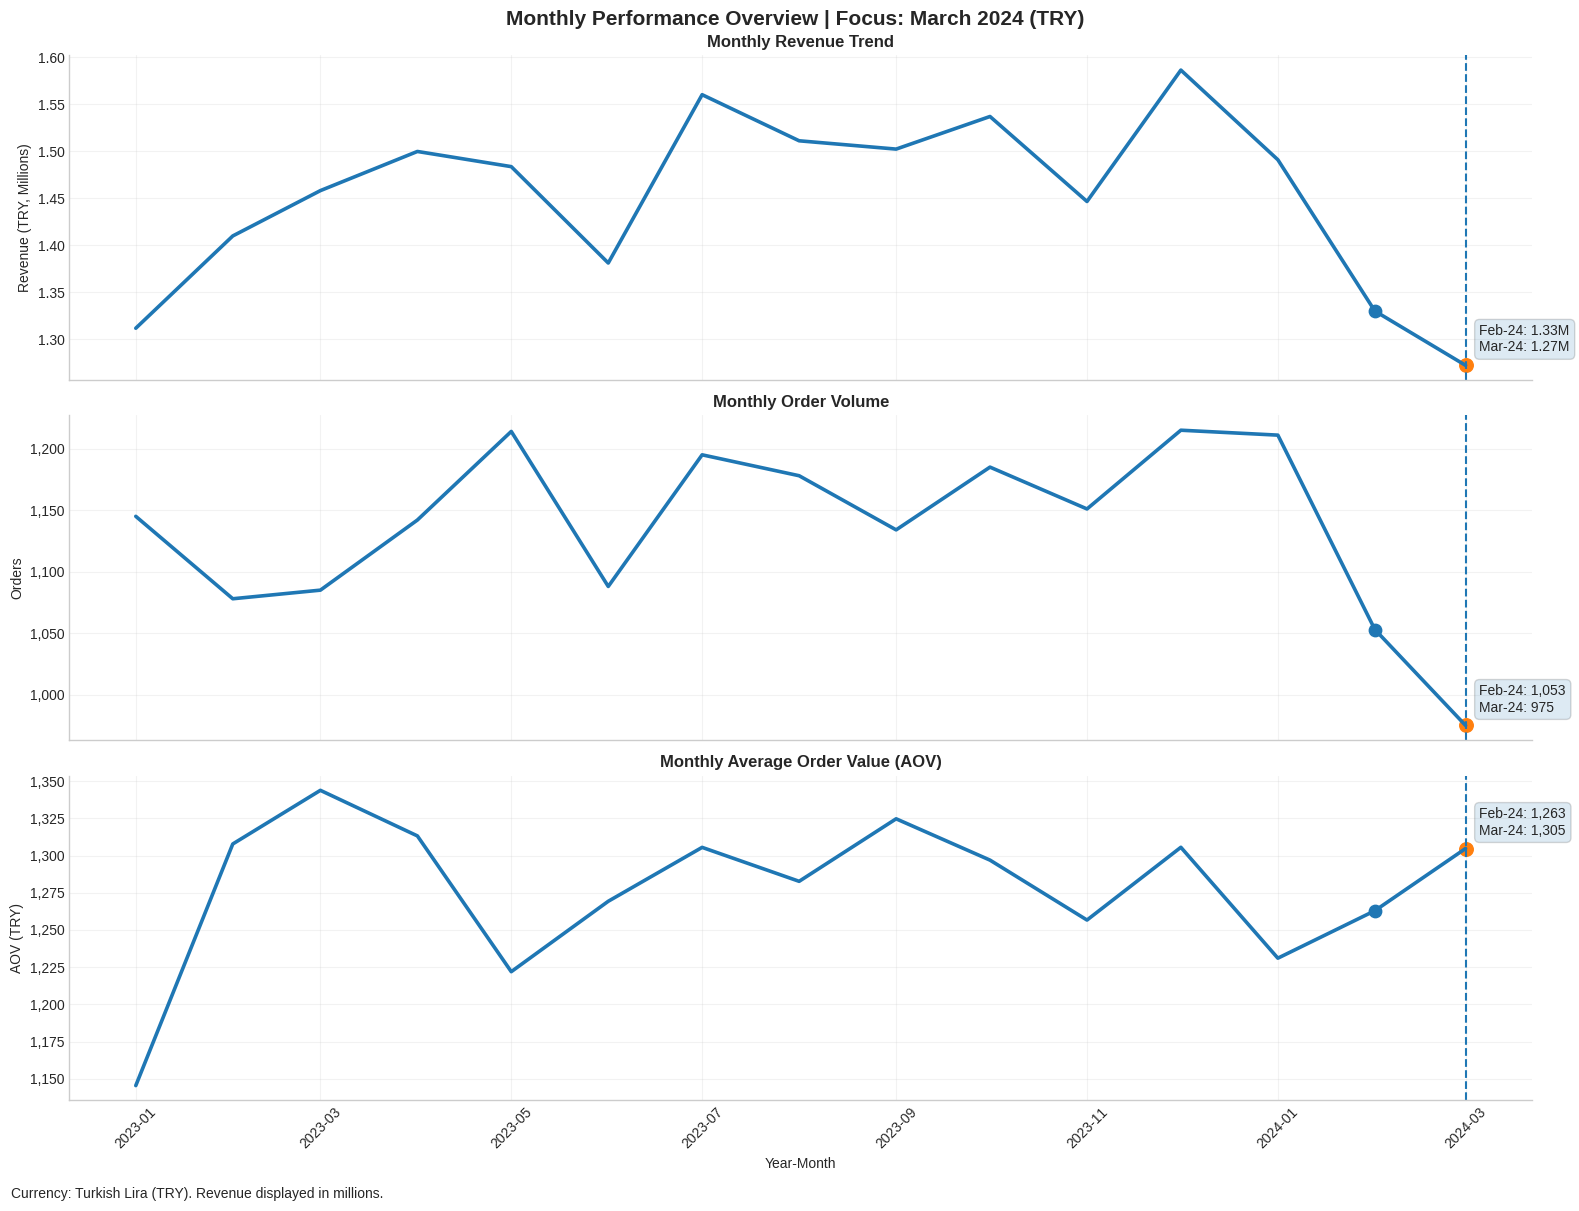

In [110]:
## Monthly KPI Trends (Currency = TRY) ##

# Aggregate monthly revenue and orders
monthly = (
    ecom_df
    .groupby('year_month')
    .agg(
        revenue=('Total_Amount', 'sum'),
        orders=('Order_ID', 'nunique')
    )
)

# Calculate Monthly AOV
monthly['aov'] = monthly['revenue'] / monthly['orders']

# Reset index and convert Period -> Timestamp
monthly = monthly.reset_index()
monthly['year_month'] = monthly['year_month'].dt.to_timestamp()

# Convert revenue to millions (executive scale)
monthly['revenue_m'] = monthly['revenue'] / 1_000_000

# Sort chronologically (important for last-month logic)
monthly = monthly.sort_values('year_month').reset_index(drop=True)

# Identify focus month (last month) and previous month (for comparison)
focus_month = monthly['year_month'].iloc[-1]
prev_month  = monthly['year_month'].iloc[-2]

focus_row = monthly.iloc[-1]
prev_row  = monthly.iloc[-2]

# Create labels for annotation (e.g., Feb-24, Mar-24)
focus_label = focus_month.strftime("%b-%y")
prev_label  = prev_month.strftime("%b-%y")

# Style
plt.style.use("seaborn-v0_8-whitegrid")

# setting figure size
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), sharex=True)


# Monthly Revenue (TRY M)

ax[0].plot(monthly['year_month'], monthly['revenue_m'], linewidth=2.6)

# Vertical marker for focus month + highlight points
ax[0].axvline(focus_month, linestyle='--', linewidth=1.5)
ax[0].scatter([prev_month],  [prev_row['revenue_m']],  s=80)
ax[0].scatter([focus_month], [focus_row['revenue_m']], s=95)

# setting up labels
ax[0].set_title("Monthly Revenue Trend", weight='bold')
ax[0].set_ylabel("Revenue (TRY, Millions)")
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.2f}"))

# Annotate previous vs focus month
ax[0].annotate(
    f"{prev_label}: {prev_row['revenue_m']:.2f}M\n{focus_label}: {focus_row['revenue_m']:.2f}M",
    xy=(focus_month, focus_row['revenue_m']),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)

# Monthly Order Volume

ax[1].plot(monthly['year_month'], monthly['orders'], linewidth=2.6)

ax[1].axvline(focus_month, linestyle='--', linewidth=1.5)
ax[1].scatter([prev_month],  [prev_row['orders']],  s=80)
ax[1].scatter([focus_month], [focus_row['orders']], s=95)

ax[1].set_title("Monthly Order Volume", weight='bold')
ax[1].set_ylabel("Orders")
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax[1].annotate(
    f"{prev_label}: {prev_row['orders']:,.0f}\n{focus_label}: {focus_row['orders']:,.0f}",
    xy=(focus_month, focus_row['orders']),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)


# Plot 3: Monthly AOV (TRY)

ax[2].plot(monthly['year_month'], monthly['aov'], linewidth=2.6)

ax[2].axvline(focus_month, linestyle='--', linewidth=1.5)
ax[2].scatter([prev_month],  [prev_row['aov']],  s=80)
ax[2].scatter([focus_month], [focus_row['aov']], s=95)

ax[2].set_title("Monthly Average Order Value (AOV)", weight='bold')
ax[2].set_ylabel("AOV (TRY)")
ax[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax[2].annotate(
    f"{prev_label}: {prev_row['aov']:,.0f}\n{focus_label}: {focus_row['aov']:,.0f}",
    xy=(focus_month, focus_row['aov']),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
)


# X-axis formatting + clean up

ax[2].set_xlabel("Year-Month")
plt.xticks(rotation=45)

for a in ax:
    a.grid(True, alpha=0.25)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.suptitle("Monthly Performance Overview | Focus: March 2024 (TRY)", fontsize=15, weight='bold')
fig.text(0.01, -0.01, "Currency: Turkish Lira (TRY). Revenue displayed in millions.", fontsize=10)

plt.tight_layout()
plt.show()

March 2024 revenue declined from **1.33M TRY in February to 1.27M TRY**, representing a clear month-over-month contraction. The primary driver of this decline was a significant reduction in **order volume (1,053 → 975)**, while **AOV increased (1,263 → 1,305 TRY)**.

This indicates that monetization efficiency and pricing strength remained intact; however, transaction volume weakened. The downturn is therefore **volume-driven rather than value-driven**, suggesting potential demand-side pressure such as reduced traffic, lower conversion rates, or external market factors.

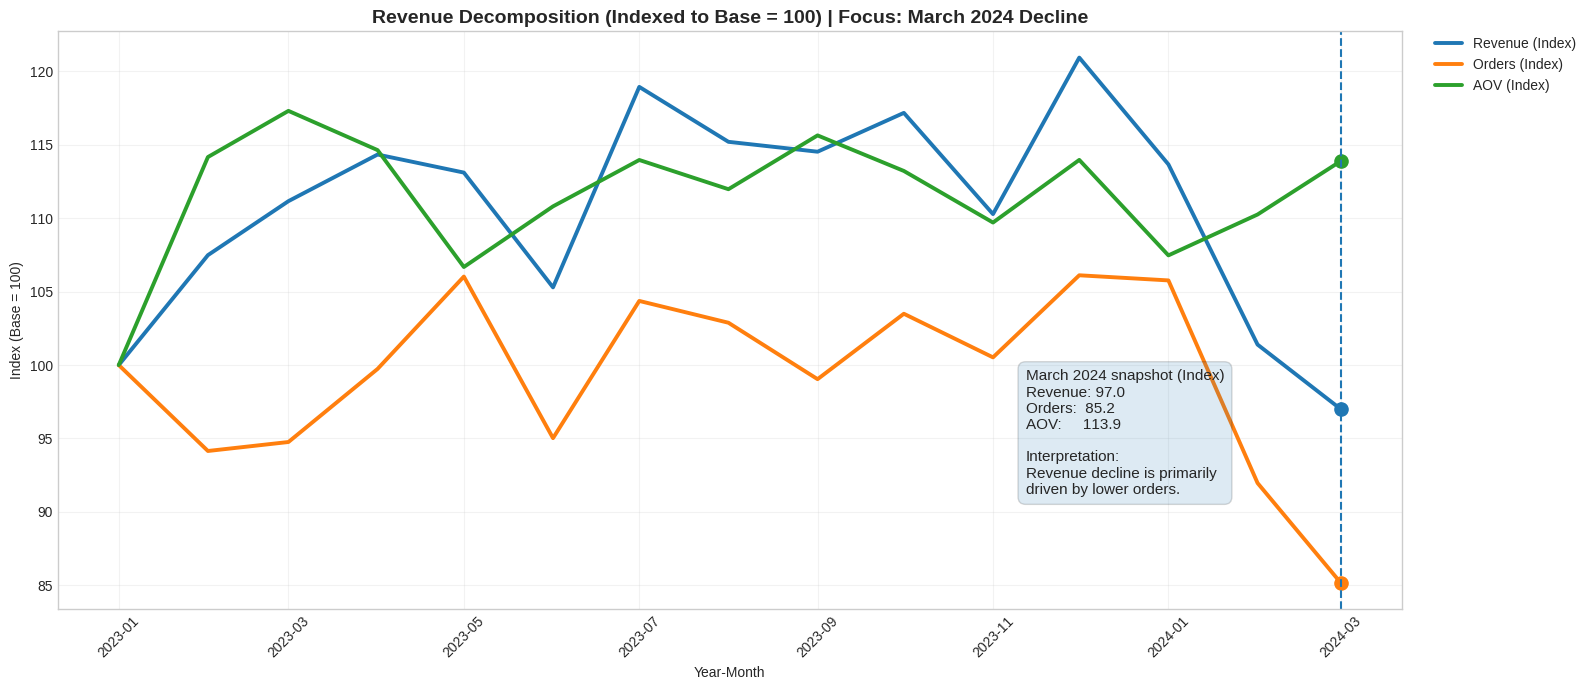

In [128]:
## Revenue Decomposition (Indexed) ##
## Focus: Diagnose the March 2024 decline ##

# sorting monthly chronologically
monthly = monthly.sort_values('year_month').copy()

# Creating indexed metrics (Base = first month = 100)
monthly_indexed = monthly.copy()
base = monthly_indexed[['revenue', 'orders', 'aov']].iloc[0]

monthly_indexed['revenue_idx'] = (monthly_indexed['revenue'] / base['revenue']) * 100
monthly_indexed['orders_idx']  = (monthly_indexed['orders']  / base['orders'])  * 100
monthly_indexed['aov_idx']     = (monthly_indexed['aov']     / base['aov'])     * 100

# Preparing the last month (focus month) for annotation
focus_month = monthly_indexed['year_month'].max()          # expected: 2024-03
focus_row   = monthly_indexed.loc[monthly_indexed['year_month'] == focus_month].iloc[0]

# Step 4: Plot (clean consulting style)
plt.figure(figsize=(16, 7))

sns.lineplot(x='year_month', y='revenue_idx', data=monthly_indexed, label='Revenue (Index)', linewidth=2.8)
sns.lineplot(x='year_month', y='orders_idx',  data=monthly_indexed, label='Orders (Index)',  linewidth=2.8)
sns.lineplot(x='year_month', y='aov_idx',     data=monthly_indexed, label='AOV (Index)',     linewidth=2.8)

# Adding a vertical marker for March 2024 + highlight points
plt.axvline(x=focus_month, linestyle='--', linewidth=1.5)
plt.scatter([focus_month], [focus_row['revenue_idx']], s=90)
plt.scatter([focus_month], [focus_row['orders_idx']],  s=90)
plt.scatter([focus_month], [focus_row['aov_idx']],     s=90)

# Adding a callout explaining the decomposition in March
callout = (
    f"March 2024 snapshot (Index)\n"
    f"Revenue: {focus_row['revenue_idx']:.1f}\n"
    f"Orders:  {focus_row['orders_idx']:.1f}\n"
    f"AOV:     {focus_row['aov_idx']:.1f}\n\n"
    f"Interpretation:\n"
    f"Revenue decline is primarily\n"
    f"driven by lower orders.")

plt.text(
    0.72, 0.20, callout,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.15)
)

# Titles, labels, formatting
plt.title("Revenue Decomposition (Indexed to Base = 100) | Focus: March 2024 Decline", fontsize=14, weight='bold')
plt.xlabel("Year-Month")
plt.ylabel("Index (Base = 100)")

# Rotate x labels for readability
plt.xticks(rotation=45)

# Subtle grid + clean layout
plt.grid(True, alpha=0.25)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

Revenue decomposition (indexed to base month = 100) shows that the March 2024 decline was primarily volume-driven. While AOV remained elevated at an index level of 113.9, order volume declined sharply to 85.2, leading revenue to fall to 97.0. This indicates that the contraction was not caused by pricing or customer spend intensity, but by a reduction in transaction volume. The primary driver of the downturn is therefore **demand-side weakness** rather than **monetization efficiency**.

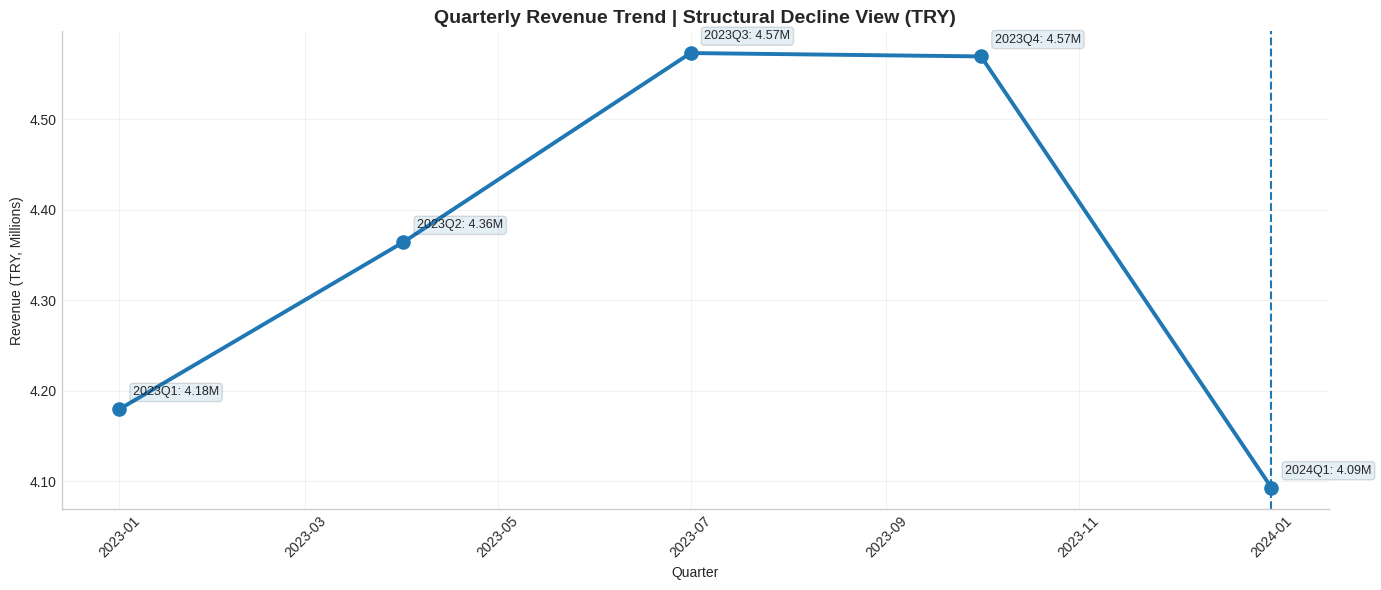

In [130]:
## Quarterly Revenue Trend (Structural View) ##
## Annotate ALL quarters with revenue (TRY, Millions) ##

# Aggregate revenue by quarter
quarterly = (
    ecom_df
    .groupby('quarter')
    .agg(revenue=('Total_Amount', 'sum'))
    .reset_index()
)

# Sort chronologically (Period sorts correctly)
quarterly = quarterly.sort_values('quarter').reset_index(drop=True)

# Convert Period -> Timestamp for plotting
quarterly['quarter_ts'] = quarterly['quarter'].dt.to_timestamp()

# Convert revenue to millions
quarterly['revenue_m'] = quarterly['revenue'] / 1_000_000

# Identify latest quarter (for vertical marker)
focus_quarter = quarterly['quarter_ts'].iloc[-1]

# Style
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(14, 6))

# Plot line
plt.plot(quarterly['quarter_ts'], quarterly['revenue_m'], linewidth=2.8)

# Mark points
plt.scatter(quarterly['quarter_ts'], quarterly['revenue_m'], s=90)

# Vertical marker for latest quarter
plt.axvline(focus_quarter, linestyle='--', linewidth=1.5)

# Titles & labels
plt.title("Quarterly Revenue Trend | Structural Decline View (TRY)", fontsize=14, weight='bold')
plt.xlabel("Quarter")
plt.ylabel("Revenue (TRY, Millions)")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.2f}"))

# Annotate each quarter with its revenue
for i in range(len(quarterly)):

    q_label = str(quarterly.loc[i, 'quarter'])
    rev_val = quarterly.loc[i, 'revenue_m']
    x_val   = quarterly.loc[i, 'quarter_ts']
    y_val   = quarterly.loc[i, 'revenue_m']

    plt.annotate(
        f"{q_label}: {rev_val:.2f}M",
        xy=(x_val, y_val),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.12)
    )

plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

While the prior section examined the March 2024 monthly decline, the quarterly aggregation confirms that the slowdown is structural rather than isolated. Revenue peaked in Q3-Q4 2023 at approximately 4.57M TRY before contracting to 4.09M TRY in Q1 2024. This represents a sustained quarter-over-quarter decline, indicating that March reflects an acceleration within an existing downward trend rather than a one-off event. The performance deterioration in Q1 suggests broader demand-side weakness extending beyond monthly volatility.

# Revenue Decomposition

In [113]:
# Define benchmark (Q4 2023) and decline period (Q1 2024) using Period objects
q4_2023 = pd.Period("2023Q4", freq="Q")
q1_2024 = pd.Period("2024Q1", freq="Q")

# Filter dataset to include only transactions from the two quarters of interest
df_attr = ecom_df[ecom_df['quarter'].isin([q4_2023, q1_2024])].copy()

In [114]:
# Defining a reusable function
def segment_attribution(df, segment_col, prior_q, decline_q):

    # Aggregate revenue by segment and quarter
    agg = (
        df
        .groupby([segment_col, 'quarter'])
        .agg(revenue=('Total_Amount', 'sum'))
        .reset_index()
    )

    # Pivot for comparison
    pivot = (
        agg
        .pivot(index=segment_col,
               columns='quarter',
               values='revenue')
        .fillna(0)
    )

    # Ensure both quarters exist
    for q in [prior_q, decline_q]:
        if q not in pivot.columns:
            pivot[q] = 0

    pivot = pivot.rename(columns={
        prior_q: 'prior_revenue',
        decline_q: 'current_revenue'
    })

    # Revenue change
    pivot['revenue_change'] = pivot['current_revenue'] - pivot['prior_revenue']

    # Total revenue change
    total_change = pivot['revenue_change'].sum()

    # Contribution %
    pivot['contribution_%'] = (
        pivot['revenue_change'] / total_change * 100
        if total_change != 0 else 0
    )

    # Revenue share in decline quarter
    decline_total = pivot['current_revenue'].sum()

    pivot['current_revenue_share_%'] = (
        pivot['current_revenue'] / decline_total * 100
        if decline_total != 0 else 0
    )

    # Rank by most negative impact
    pivot = pivot.sort_values('revenue_change')
    pivot['impact_rank'] = range(1, len(pivot) + 1)

    return pivot

In [115]:
# Revenue by Product Category
product_attr = segment_attribution(
    df_attr,
    'Product_Category',
    q4_2023,
    q1_2024
)

product_attr.head(10)

quarter,prior_revenue,current_revenue,revenue_change,contribution_%,current_revenue_share_%,impact_rank
Product_Category,,,,,,
Electronics,2148652.15,1947673.23,-200978.92,42.16,47.59,1
Home & Garden,895137.34,770861.12,-124276.22,26.07,18.83,2
Fashion,349191.78,282537.26,-66654.52,13.98,6.90,3
Beauty,152478.33,122241.42,-30236.91,6.34,2.99,4
Sports,661309.95,636511.39,-24798.56,5.20,15.55,5
Food,88957.43,73832.78,-15124.65,3.17,1.80,6
Toys,199934.46,188114.75,-11819.71,2.48,4.60,7
Books,73839.45,71038.83,-2800.62,0.59,1.74,8


Product category attribution indicates that revenue declines were observed across most categories in Q1 2024, reinforcing the view of broad-based demand contraction. However, the financial impact of the slowdown is disproportionately concentrated within Electronics and Home & Garden, which together account for approximately 68% of the total quarter-over-quarter revenue decline. Given their dominant revenue share, performance deterioration within these high-volume segments materially influences overall revenue outcomes. The contraction is therefore systemic in direction but economically concentrated in the largest revenue-generating categories.

In [116]:
# Revenue by Device
device_attr = segment_attribution(
    df_attr,
    'Device_Type',
    q4_2023,
    q1_2024
)

device_attr.head()

quarter,prior_revenue,current_revenue,revenue_change,contribution_%,current_revenue_share_%,impact_rank
Device_Type,,,,,,
Desktop,1683770.47,1374617.89,-309152.58,64.85,33.59,1
Mobile,2455796.51,2293187.56,-162608.95,34.11,56.03,2
Tablet,429933.91,425005.33,-4928.58,1.03,10.38,3


Device-level attribution indicates that the Q1 2024 revenue contraction was disproportionately driven by Desktop performance, which accounts for approximately 65% of the total quarter-over-quarter decline despite representing only 34% of Q1 revenue share. In contrast, Mobile, while contributing over half of total revenue, exhibited comparatively smaller contraction. This suggests that the structural slowdown may be channel-sensitive, with Desktop demand or conversion weakening more materially than Mobile.

In [117]:
# Revenue by City
city_attr = segment_attribution(
    df_attr,
    'City',
    q4_2023,
    q1_2024
)

city_attr.head(10)

quarter,prior_revenue,current_revenue,revenue_change,contribution_%,current_revenue_share_%,impact_rank
City,,,,,,
Istanbul,1257031.85,955797.76,-301234.09,63.19,23.35,1
Antalya,388501.32,291864.30,-96637.02,20.27,7.13,2
Bursa,460253.48,419429.88,-40823.60,8.56,10.25,3
Izmir,542229.21,509933.39,-32295.82,6.78,12.46,4
Kayseri,225945.41,196107.45,-29837.96,6.26,4.79,5
Eskisehir,186479.27,158999.91,-27479.36,5.76,3.88,6
Konya,315632.88,305576.15,-10056.73,2.11,7.47,7
Adana,270364.87,270568.44,203.57,-0.04,6.61,8
Ankara,623564.10,625427.44,1863.34,-0.39,15.28,9


City-level attribution reveals that the Q1 2024 revenue contraction was highly concentrated in Istanbul, which accounts for approximately 63% of the total quarter-over-quarter decline despite representing only 23% of Q1 revenue share. While several secondary cities experienced moderate declines, others demonstrated stable or positive growth, indicating that the slowdown is geographically concentrated rather than uniformly national. This suggests that structural demand weakness may be localized, with Istanbul representing the primary driver of revenue contraction.

In [118]:
# Revenue by Returning vs New Customers
customer_attr = segment_attribution(
    df_attr,
    'Is_Returning_Customer',
    q4_2023,
    q1_2024
)

customer_attr

quarter,prior_revenue,current_revenue,revenue_change,contribution_%,current_revenue_share_%,impact_rank
Is_Returning_Customer,,,,,,
True,4331513.67,3998146.87,-333366.80,69.93,97.69,1
False,237987.22,94663.91,-143323.31,30.07,2.31,2


Customer-type attribution reveals that the Q1 2024 revenue contraction was predominantly driven by returning customers, who account for nearly 98% of Q1 revenue and approximately 70% of the total quarter-over-quarter decline. While new customer revenue also declined, its overall impact on total revenue was limited due to its smaller revenue base. This suggests that the structural slowdown is rooted in reduced purchasing activity among existing customers rather than solely in acquisition weakness.

In [119]:
# Aggregate Revenue by 3-Way Interaction
layer2_agg = (
    df_attr
    .groupby(['City', 'Device_Type', 'Is_Returning_Customer', 'quarter'])
    .agg(revenue=('Total_Amount', 'sum'))
    .reset_index()
)

In [120]:
# Pivot for Q4 vs Q1 Comparison
layer2_pivot = (
    layer2_agg
    .pivot(index=['City', 'Device_Type', 'Is_Returning_Customer'],
           columns='quarter',
           values='revenue')
    .fillna(0)
)

# Rename columns
layer2_pivot = layer2_pivot.rename(columns={
    q4_2023: 'prior_revenue',
    q1_2024: 'current_revenue'
})

# Revenue change
layer2_pivot['revenue_change'] = (
    layer2_pivot['current_revenue'] -
    layer2_pivot['prior_revenue']
)

In [121]:
# Sort by Largest Negative Impact
layer2_pivot = layer2_pivot.sort_values('revenue_change')

layer2_pivot.head(10)

quarter                                      prior_revenue  current_revenue  revenue_change
City      Device_Type Is_Returning_Customer                                                
Istanbul  Desktop     True                       448438.59        304138.28      -144300.31
          Mobile      True                       633091.83        503856.33      -129235.50
Antalya   Mobile      True                       216831.10        145519.45       -71311.65
Izmir     Desktop     True                       235034.32        170234.90       -64799.42
Antalya   Desktop     True                       131184.33         90892.31       -40292.02
Eskisehir Desktop     True                        74307.87         45759.09       -28548.78
Bursa     Desktop     True                       188190.88        159953.69       -28237.19
Ankara    Mobile      True                       366934.04        339296.96       -27637.08
Bursa     Tablet      True                        51676.96         24394.57       -27282.39
Istanbul  Mobile      False                       43538.81         25683.44       -17855.37

In [122]:
layer2_plot = layer2_pivot.copy()

# Reset index so City, Device_Type, Customer are columns
layer2_plot = layer2_plot.reset_index()

# Create readable label
layer2_plot['segment_label'] = (
    layer2_plot['City'] + " | " +
    layer2_plot['Device_Type'] + " | " +
    layer2_plot['Is_Returning_Customer'].astype(str)
)

In [123]:
# Top 10 Negative Contributors
top10_decline = (
    layer2_plot
    .sort_values('revenue_change')
    .head(10)
)

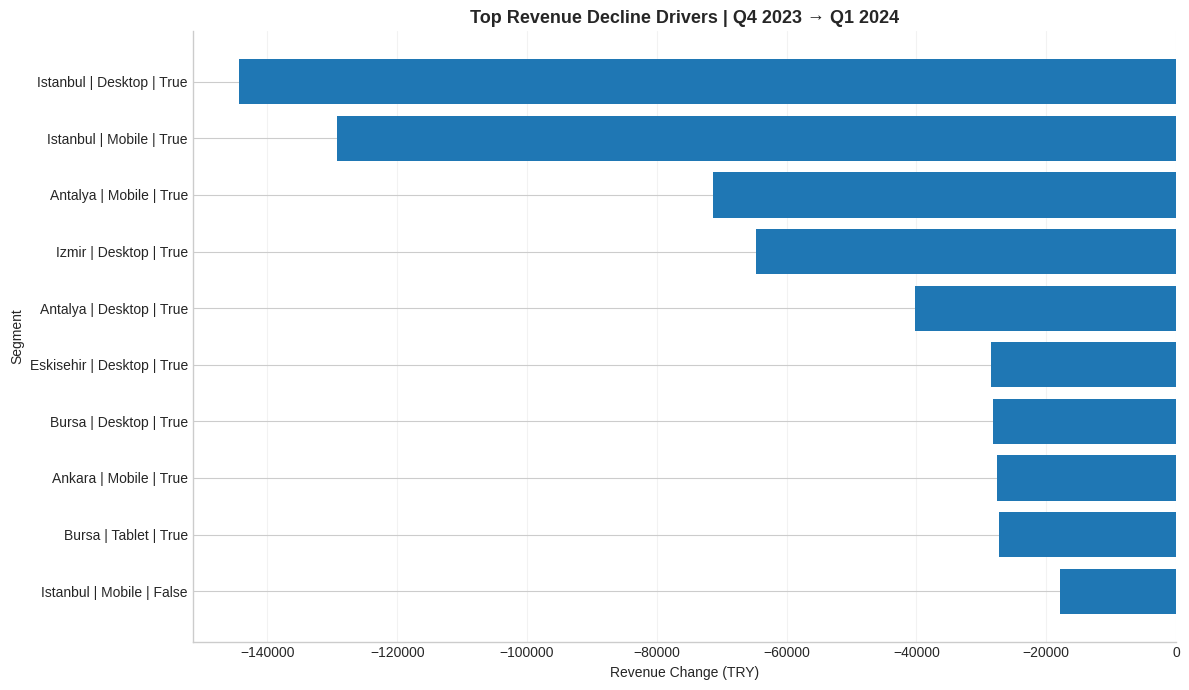

In [132]:
# Horizontal Bar Chart
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(12,7))

bars = plt.barh(
    top10_decline['segment_label'],
    top10_decline['revenue_change']
)

plt.title("Top Revenue Decline Drivers | Q4 2023 → Q1 2024",
          fontsize=13, weight='bold')

plt.xlabel("Revenue Change (TRY)")
plt.ylabel("Segment")

plt.gca().invert_yaxis()  # largest decline at top
plt.grid(axis='x', alpha=0.25)

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

The interaction-level revenue decomposition confirms that the structural contraction in Q1 2024 is concentrated within returning customers in major metropolitan markets, particularly Istanbul. The single largest contributor to revenue decline is the Istanbul | Desktop | Returning segment, followed closely by Istanbul | Mobile | Returning. Together, these two segments account for a substantial portion of the total quarter-over-quarter contraction.

The pattern indicates that the slowdown is not driven by acquisition weakness but rather by reduced purchasing activity among the existing customer base in high-volume urban markets. Desktop traffic among returning customers appears disproportionately affected, suggesting potential behavioral, channel-specific, or localized demand shifts.

Overall, the contraction is volume-driven, returning-customer-heavy, metro-concentrated, and particularly pronounced in Istanbul across both Desktop and Mobile channels.

# Behavioral Attribution

In [125]:
# Define Period Subset
q4_2023 = pd.Period("2023Q4", freq="Q")
q1_2024 = pd.Period("2024Q1", freq="Q")

df_behavior = ecom_df[ecom_df['quarter'].isin([q4_2023, q1_2024])].copy()

In [126]:
# Aggregate Behavioral KPIs by Quarter
behavior_summary = (
    df_behavior
    .groupby('quarter')
    .agg(
        avg_session_duration=('Session_Duration_Minutes', 'mean'),
        avg_pages_viewed=('Pages_Viewed', 'mean'),
        discount_rate=('Discount_Amount', lambda x: (x > 0).mean()),
        avg_delivery_time=('Delivery_Time_Days', 'mean')
    )
    .reset_index()
)

behavior_summary

,quarter,avg_session_duration,avg_pages_viewed,discount_rate,avg_delivery_time
0,2023Q4,14.49,9.00,0.39,6.51
1,2024Q1,14.56,9.04,0.38,6.48


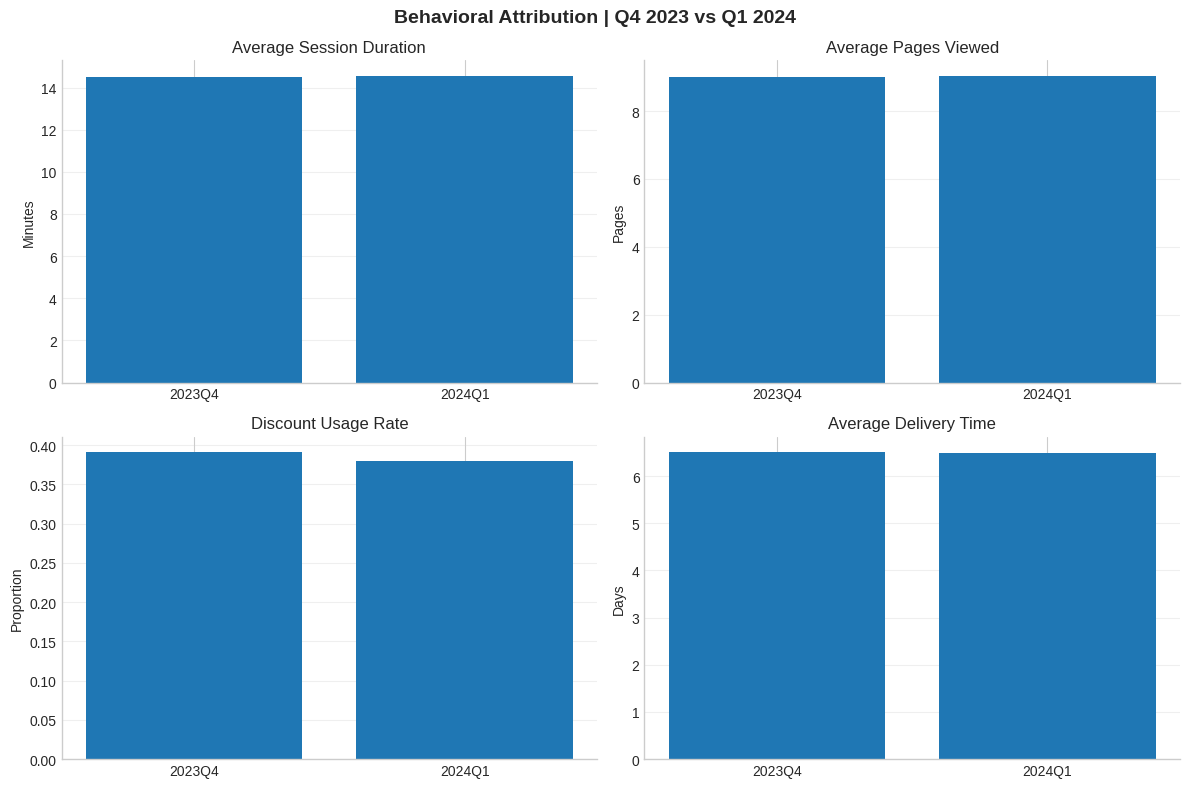

In [135]:
# Plotting Behavioral Trends
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

# Average Session Duration

ax[0,0].bar(
    behavior_summary['quarter'].astype(str),
    behavior_summary['avg_session_duration']
)
ax[0,0].set_title("Average Session Duration")
ax[0,0].set_ylabel("Minutes")


# Average Pages Viewed

ax[0,1].bar(
    behavior_summary['quarter'].astype(str),
    behavior_summary['avg_pages_viewed']
)
ax[0,1].set_title("Average Pages Viewed")
ax[0,1].set_ylabel("Pages")


# Discount Usage Rate

ax[1,0].bar(
    behavior_summary['quarter'].astype(str),
    behavior_summary['discount_rate']
)
ax[1,0].set_title("Discount Usage Rate")
ax[1,0].set_ylabel("Proportion")



# Average Delivery Time

ax[1,1].bar(
    behavior_summary['quarter'].astype(str),
    behavior_summary['avg_delivery_time']
)
ax[1,1].set_title("Average Delivery Time")
ax[1,1].set_ylabel("Days")


# Clean up layout
for a in ax.flat:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(axis='y', alpha=0.3)

fig.suptitle(
    "Behavioral Attribution | Q4 2023 vs Q1 2024",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.show()

Behavioral metrics remained broadly stable between Q4 2023 and Q1 2024. **Session duration**, **page depth**, **discount utilization**, and **delivery time** showed no material deterioration. This suggests that **customer engagement quality** and **operational performance** were not primary drivers of the revenue contraction. Instead, the decline appears to stem from reduced purchase frequency or lower traffic volume, particularly among returning customers in major metropolitan markets.

# Strategic Insights & Recommendations

🔷 **Strategic Insights**

1️⃣**Revenue Contraction Is Volume-Driven**

The Q1 2024 decline is primarily driven by reduced order volume, not pricing or basket compression. AOV remained stable, indicating monetization strength per transaction.

**Implication:** The issue lies in demand frequency or traffic volume, not pricing power.

2️⃣ **Contraction Is Broad but Economically Concentrated**

Revenue declines were observed across product categories; however, the financial impact is disproportionately concentrated in high-revenue categories such as Electronics and Home & Garden.

**Implication:** Portfolio exposure risk is concentrated in large categories.

3️⃣ **Returning Customers Are the Core Driver**

Approximately 70% of the total contraction is driven by returning customers, who represent nearly 98% of revenue.

**Implication:** The slowdown reflects reduced purchasing activity among the existing customer base - not primarily acquisition weakness.

4️⃣ **Desktop Engagement Is Disproportionately Affected**

Desktop accounts for the largest share of revenue contraction relative to its revenue mix.

**Implication:** Channel-specific behavioral or demand shifts may be occurring.

5️⃣ **Geographic Concentration in Istanbul**

Istanbul represents over 60% of the total revenue decline despite representing a smaller share of Q1 revenue.

**Implication:** The contraction is geographically concentrated rather than uniformly national.

6️⃣ **Behavioral & Operational Metrics Remain Stable**

Session duration, page depth, discount utilization, and delivery time did not materially deteriorate.

**Implication:** Engagement quality and fulfillment performance are not primary drivers.



🔷 **Strategic Diagnosis**

The structural contraction in Q1 2024 appears to reflect:

Reduced purchase frequency among returning customers in major metropolitan markets, particularly Istanbul, with Desktop traffic disproportionately affected.

This suggests demand-side deceleration rather than pricing failure, operational breakdown, or conversion collapse.

🔷 **Strategic Recommendations**

1️⃣ **Re-Engage the Returning Customer Base**

Focus on retention activation in Istanbul:

Targeted reactivation campaigns

Personalized offers for dormant repeat buyers

Frequency-based loyalty incentives

**Priority: High**


2️⃣ **Investigate Desktop Funnel Performance**

Conduct a Desktop-specific diagnostic:

Traffic volume trends

Conversion rate shifts

Device-specific UX performance

Channel mix changes

**Priority: High**


3️⃣ **Metro-Level Marketing Allocation Review**

Reassess spend allocation in Istanbul:

Has paid acquisition declined?

Has channel mix shifted?

Has competition intensified?

**Priority: Medium-High**


4️⃣ **Protect High-Revenue Categories**

Given exposure concentration in Electronics and Home & Garden:

Consider targeted promotional reinforcement

Evaluate price elasticity sensitivity

Monitor competitive pricing

**Priority: Medium**


5️⃣ **Monitor Repeat Purchase Frequency**

Track:

Time between purchases

Frequency decay patterns

Cohort-level repeat behavior

This will confirm whether contraction is frequency-driven vs traffic-driven.

**Priority: Ongoing**

# Final Executive Conclusion

Revenue declined in Q1 2024 relative to Q4 2023, with March representing an acceleration within a broader contraction phase. Decomposition analysis confirms that the slowdown was **volume-driven**, as Average Order Value remained stable while order volume declined materially. Product-level attribution shows that while declines were observed across most categories, the financial impact was concentrated in high-revenue segments such as Electronics and Home & Garden due to their dominant portfolio share.

Channel and geographic attribution further narrowed the contraction to **Desktop traffic and major metropolitan markets**, particularly Istanbul, which accounted for a disproportionate share of total revenue decline. Customer-type analysis indicates that approximately 70% of the contraction was driven by **returning customers**, suggesting reduced purchase frequency among the existing customer base rather than primary acquisition failure.

Behavioral and operational metrics remained stable during the decline period. Session duration, page depth, discount utilization, and delivery time showed no material deterioration, indicating that engagement quality and fulfillment performance were not primary drivers of revenue loss.

Overall, the Q1 contraction appears to reflect **reduced purchasing activity among returning customers in high-volume urban markets**, with Desktop disproportionately affected. The evidence suggests demand-side deceleration rather than pricing weakness, conversion collapse, or operational friction.

Strategic focus should therefore center on reactivating the returning customer base, investigating Desktop-specific performance in Istanbul, and evaluating potential shifts in traffic mix or marketing allocation during Q1 2024.